07a — M1 NeuroKit2, DÉTECTEUR COMBINÉ (PTB-XL + Ningbo)

In [1]:
# ════════════════════════════════════════════════════════════════════════════
# NOTEBOOK 07a — M1 NeuroKit2, DÉTECTEUR COMBINÉ (PTB-XL + Ningbo)
# Tournoi A/B/C/D façon eda_marquette. Juge : AP. Fold 10 VIERGE.
# ════════════════════════════════════════════════════════════════════════════
# Bloc 7.0a — Setup, chemins, filtre figé, dérivations, intégrité.  PERMANENT
import os, sys, json
import numpy as np
import pandas as pd

ROOT      = r'C:\Users\natha\Documents\ML_WPW\wpw_project_v2'
PROCESSED = os.path.join(ROOT, 'data', 'processed')
MODELS    = os.path.join(ROOT, 'models', 'M1_neurokit')
SRC       = os.path.join(ROOT, 'src')
os.makedirs(MODELS, exist_ok=True)
sys.path.insert(0, SRC)

# Chargeur canonique (source de vérité unique du chargement signal)
from signal_loading import load_signal, LEADS_CANONICAL
print("signal_loading OK — ordre canonique :", LEADS_CANONICAL)

# Filtre FIGÉ (gravé en 06e) — lu, jamais redécidé
with open(os.path.join(PROCESSED, 'filter_config.json'), encoding='utf-8') as f:
    FCFG = json.load(f)['filter_FINAL']
assert (FCFG['low'], FCFG['high'], FCFG['order']) == (0.5, 40, 4), "Filtre inattendu !"
FS = FCFG['fs']
print(f"Filtre figé : {FCFG['type']} ordre {FCFG['order']}, {FCFG['low']}-{FCFG['high']} Hz, {FCFG['phase']}")

# Dérivations NeuroKit pour M1 (per-lead autorisé — M5 fera de l'inter-dérivations, pas de NeuroKit)
LEADS_M1 = ['II', 'V1', 'V5']
LEAD_IDX = {L: LEADS_CANONICAL.index(L) for L in LEADS_M1}
print(f"Dérivations M1 : {LEADS_M1} -> index {LEAD_IDX}")

# Fichier de features enrichi (produit en 7.1a — n'existe pas encore)
ENRICHED_CSV = os.path.join(PROCESSED, 'm1_features_enriched.csv')

# Métadonnées combinées
meta = pd.read_csv(os.path.join(PROCESSED, 'metadata_combined.csv'), dtype={'ecg_id': str})
n_wpw = int((meta.label==1).sum())
print(f"\nmetadata_combined : {len(meta)} ECG, {n_wpw} WPW")
print(f"WPW par fold : {meta[meta.label==1].groupby('fold').size().to_dict()}")
print(f"Train(1-8): {int(meta[(meta.fold.between(1,8))&(meta.label==1)].shape[0])} | "
      f"Val(9): {int(meta[(meta.fold==9)&(meta.label==1)].shape[0])} | "
      f"Test(10): {int(meta[(meta.fold==10)&(meta.label==1)].shape[0])} [VIERGE]")
assert n_wpw == 142, "Attendu 142 WPW dans le combiné !"
print("\nBloc 7.0a OK — contexte chargé, filtre vérifié. Prêt pour 7.1a (extraction enrichie).")

signal_loading OK — ordre canonique : ['I', 'II', 'III', 'AVR', 'AVL', 'AVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
Filtre figé : butterworth ordre 4, 0.5-40 Hz, zero-phase (sosfiltfilt)
Dérivations M1 : ['II', 'V1', 'V5'] -> index {'II': 1, 'V1': 6, 'V5': 10}

metadata_combined : 66951 ECG, 142 WPW
WPW par fold : {1: 16, 2: 16, 3: 15, 4: 11, 5: 14, 6: 14, 7: 15, 8: 14, 9: 13, 10: 14}
Train(1-8): 115 | Val(9): 13 | Test(10): 14 [VIERGE]

Bloc 7.0a OK — contexte chargé, filtre vérifié. Prêt pour 7.1a (extraction enrichie).


7.1a — Extraction NeuroKit2 MASSIVE (~169 features, 6 familles), parallèle 10 cœurs

In [3]:
# Bloc 7.1a — Extraction NeuroKit2 MASSIVE (~169 features, 6 familles), parallèle 10 cœurs.  PERMANENT
# Filtre 0.5-40 sur chaque dérivation. Testé end-to-end. GARDE-FOU anti-relance. Run nocturne ~60-90 min.
FORCE_REEXTRACT = False

if os.path.exists(ENRICHED_CSV) and not FORCE_REEXTRACT:
    print(f"{ENRICHED_CSV} existe déjà — extraction SAUTÉE (FORCE_REEXTRACT=True pour régénérer).")
else:
    import warnings, time, contextlib
    import neurokit2 as nk
    from scipy.signal import butter, sosfiltfilt
    from scipy.stats import skew, kurtosis
    from joblib import Parallel, delayed
    from tqdm import tqdm
    warnings.filterwarnings('ignore')

    SOS_BP = butter(FCFG['order'], [FCFG['low']/(FS/2), FCFG['high']/(FS/2)], btype='band', output='sos')
    def bp(x): return sosfiltfilt(SOS_BP, np.asarray(x, dtype=np.float64))

    @contextlib.contextmanager
    def tqdm_joblib(t):
        import joblib
        class _Cb(joblib.parallel.BatchCompletionCallBack):
            def __call__(self,*a,**k): t.update(n=self.batch_size); return super().__call__(*a,**k)
        old=joblib.parallel.BatchCompletionCallBack; joblib.parallel.BatchCompletionCallBack=_Cb
        try: yield t
        finally: joblib.parallel.BatchCompletionCallBack=old; t.close()

    def _med(v):
        v=np.asarray([x for x in v if x is not None and np.isfinite(x)],float)
        return float(np.median(v)) if v.size else np.nan
    def _std(v):
        v=np.asarray([x for x in v if x is not None and np.isfinite(x)],float)
        return float(np.std(v)) if v.size>=2 else np.nan
    def _cv(v):
        v=np.asarray([x for x in v if x is not None and np.isfinite(x)],float)
        return float(np.std(v)/abs(np.mean(v))) if v.size>=2 and abs(np.mean(v))>1e-9 else np.nan

    def delineate(s):
        _, info = nk.ecg_peaks(s, sampling_rate=FS); rp=info['ECG_R_Peaks']
        if rp is None or len(rp)<3: return None, None
        _, w = nk.ecg_delineate(s, rpeaks=rp, sampling_rate=FS, method='dwt')
        return np.asarray(rp), w

    # ===== POOL CLINIQUE (II, scalaire global) =====
    CLIN=['PR_ms','QRS_ms','QT_ms','P_ms','PR_seg_ms','ST_seg_ms','RR_mean','RR_std','HR','n_beats','QRS_ms_std','QT_ms_std','P_amp_glob']
    def clinical(s):
        o={k:np.nan for k in CLIN}
        rp,w=delineate(s)
        if rp is None: return o,True
        rpf=np.asarray(rp,float); rr=np.diff(rpf)/FS*1000
        o['RR_mean']=float(np.nanmean(rr)) if rr.size else np.nan
        o['RR_std']=float(np.nanstd(rr)) if rr.size else np.nan
        o['HR']=60000/o['RR_mean'] if o['RR_mean'] and o['RR_mean']>0 else np.nan
        o['n_beats']=int(len(rpf))
        Pon=np.asarray(w.get('ECG_P_Onsets',[]),float); Poff=np.asarray(w.get('ECG_P_Offsets',[]),float)
        Ppk=np.asarray(w.get('ECG_P_Peaks',[]),float)
        Ron=np.asarray(w.get('ECG_R_Onsets',[]),float); Roff=np.asarray(w.get('ECG_R_Offsets',[]),float)
        Toff=np.asarray(w.get('ECG_T_Offsets',[]),float); Tpk=np.asarray(w.get('ECG_T_Peaks',[]),float)
        n=min(len(Pon),len(Ron))
        if n: o['PR_ms']=_med([(Ron[i]-Pon[i])/FS*1000 for i in range(n) if np.isfinite(Pon[i]) and np.isfinite(Ron[i]) and Ron[i]>Pon[i]])
        m=min(len(Ron),len(Roff))
        if m:
            qrs=[(Roff[i]-Ron[i])/FS*1000 for i in range(m) if np.isfinite(Ron[i]) and np.isfinite(Roff[i]) and Roff[i]>Ron[i]]
            o['QRS_ms']=_med(qrs); o['QRS_ms_std']=_std(qrs)
        k=min(len(Ron),len(Toff))
        if k:
            qt=[(Toff[i]-Ron[i])/FS*1000 for i in range(k) if np.isfinite(Ron[i]) and np.isfinite(Toff[i]) and Toff[i]>Ron[i]]
            o['QT_ms']=_med(qt); o['QT_ms_std']=_std(qt)
        p=min(len(Pon),len(Poff))
        if p: o['P_ms']=_med([(Poff[i]-Pon[i])/FS*1000 for i in range(p) if np.isfinite(Pon[i]) and np.isfinite(Poff[i]) and Poff[i]>Pon[i]])
        ps=min(len(Poff),len(Ron))
        if ps: o['PR_seg_ms']=_med([(Ron[i]-Poff[i])/FS*1000 for i in range(ps) if np.isfinite(Poff[i]) and np.isfinite(Ron[i]) and Ron[i]>Poff[i]])
        st=min(len(Roff),len(Tpk))
        if st: o['ST_seg_ms']=_med([(Tpk[i]-Roff[i])/FS*1000 for i in range(st) if np.isfinite(Roff[i]) and np.isfinite(Tpk[i]) and Tpk[i]>Roff[i]])
        pk=Ppk[np.isfinite(Ppk)].astype(int); pk=pk[(pk>=0)&(pk<len(s))]
        o['P_amp_glob']=_med(s[pk]) if pk.size else np.nan
        return o,False

    # ===== POOL DÉCOUVERTE (par dérivation) : 52 features × II/V1/V5 =====
    DISC_BASES=(
     ['delta_slopemax20','delta_slopemax40','delta_slopemax60','delta_slopemean','delta_t_to_max',
      'delta_ratio_init_peak','delta_accel_max','delta_empatement_area','delta_slow_phase_ms',
      'delta_vel_quarter','delta_vel_half','delta_area_third']
     +['qrs_area','qrs_absarea','qrs_energy','qrs_ninflect','qrs_nzero','qrs_skew','qrs_kurt','qrs_p2p',
       'qrs_fwhm','qrs_asym','qrs_arclen','qrs_posneg_ratio','qrs_npeaks','qrs_moment3','qrs_entropy']
     +['R_amp','S_amp','Q_amp','T_amp','RS_ratio','QR_ratio','TR_ratio']
     +['st_slope','st_level_J','t_area','t_width','t_peak_time','t_symmetry','st_t_area_ratio']
     +['freq_hf_ratio','freq_hf_energy','freq_median','freq_p95','freq_lf_ratio']
     +['var_qrswidth_std','var_qrswidth_cv','var_Ramp_std','var_Ramp_cv','var_delta_std','var_delta_cv','var_area_std']
    )

    def discovery(s,rp,w,suf):
        o={f'{b}_{suf}':np.nan for b in DISC_BASES}
        if rp is None: return o
        rp=np.asarray(rp,int); Ron=np.asarray(w.get('ECG_R_Onsets',[]),float)
        Roff=np.asarray(w.get('ECG_R_Offsets',[]),float); Tpk=np.asarray(w.get('ECG_T_Peaks',[]),float)
        Toff=np.asarray(w.get('ECG_T_Offsets',[]),float)
        win40=int(0.040*FS)
        acc={k:[] for k in DISC_BASES}
        qw_bb,ramp_bb,delta_bb,area_bb=[],[],[],[]
        for i,r in enumerate(rp):
            a=max(0,r-win40)
            if r>a+3:
                seg=s[a:r+1]; d1=np.diff(seg)*FS; absd=np.abs(d1)
                for ms,key in [(20,'20'),(40,'40'),(60,'60')]:
                    n=int(ms/1000*FS); segk=s[max(0,r-n):r+1]
                    if segk.size>2: acc[f'delta_slopemax{key}'].append(float(np.max(np.abs(np.diff(segk)*FS))))
                acc['delta_slopemean'].append(float(absd.mean()))
                imax=int(np.argmax(absd)); acc['delta_t_to_max'].append(imax/FS*1000)
                init=np.mean(absd[:max(1,len(absd)//3)]); pk=absd.max()
                acc['delta_ratio_init_peak'].append(float(init/pk) if pk>1e-9 else np.nan)
                d2=np.diff(d1)*FS; acc['delta_accel_max'].append(float(np.max(np.abs(d2))) if len(d2) else np.nan)
                ideal=np.linspace(seg[0],seg[-1],len(seg)); acc['delta_empatement_area'].append(float(np.trapezoid(np.abs(seg-ideal))/FS))
                thr=0.5*pk; idx=np.where(absd>=thr)[0]; acc['delta_slow_phase_ms'].append(float(idx[0]/FS*1000) if idx.size else np.nan)
                q=len(seg)//4; h=len(seg)//2
                acc['delta_vel_quarter'].append(float((seg[q]-seg[0])/(q/FS)) if q>0 else np.nan)
                acc['delta_vel_half'].append(float((seg[h]-seg[0])/(h/FS)) if h>0 else np.nan)
                third=seg[:max(2,len(seg)//3)]; acc['delta_area_third'].append(float(np.trapezoid(np.abs(third-third[0]))/FS))
                rng=seg.max()-seg.min()
                acc['qrs_area'].append(float(np.trapezoid(seg-seg[0])/FS)); acc['qrs_absarea'].append(float(np.trapezoid(np.abs(seg-seg[0]))/FS))
                acc['qrs_energy'].append(float(np.sum(seg**2)))
                dd2=np.diff(np.sign(np.diff(seg))); acc['qrs_ninflect'].append(int(np.sum(dd2!=0)))
                acc['qrs_nzero'].append(int(np.sum(np.diff(np.sign(seg-seg.mean()))!=0)))
                if seg.size>3: acc['qrs_skew'].append(float(skew(seg))); acc['qrs_kurt'].append(float(kurtosis(seg)))
                acc['qrs_p2p'].append(float(rng))
                half=seg.min()+rng/2; above=np.where(seg>=half)[0]
                acc['qrs_fwhm'].append(float((above[-1]-above[0])/FS*1000) if above.size>1 else np.nan)
                pkp=int(np.argmax(np.abs(seg-seg[0]))); acc['qrs_asym'].append(pkp/(len(seg)-pkp) if len(seg)-pkp>0 else np.nan)
                acc['qrs_arclen'].append(float(np.sum(np.sqrt(1+np.diff(seg)**2))))
                pos=seg[seg>seg.mean()].sum(); negv=abs(seg[seg<seg.mean()].sum())
                acc['qrs_posneg_ratio'].append(float(pos/negv) if negv>1e-9 else np.nan)
                ddp=np.diff(np.sign(np.diff(seg))); acc['qrs_npeaks'].append(int(np.sum(ddp<0)))
                acc['qrs_moment3'].append(float(np.mean((seg-seg.mean())**3)))
                pp=np.abs(seg-seg.min())+1e-9; pp=pp/pp.sum(); acc['qrs_entropy'].append(float(-np.sum(pp*np.log(pp))))
                wfull=s[a:min(r+win40,len(s))]
                if wfull.size>4:
                    fftv=np.abs(np.fft.rfft(wfull-wfull.mean())); freqs=np.fft.rfftfreq(len(wfull),1/FS); tot=fftv.sum()+1e-9
                    acc['freq_hf_ratio'].append(float(fftv[(freqs>=15)&(freqs<=40)].sum()/tot))
                    acc['freq_hf_energy'].append(float((fftv[(freqs>=15)&(freqs<=40)]**2).sum()))
                    csum=np.cumsum(fftv)/tot
                    acc['freq_median'].append(float(freqs[np.searchsorted(csum,0.5)]) if csum[-1]>0 else np.nan)
                    acc['freq_p95'].append(float(freqs[min(np.searchsorted(csum,0.95),len(freqs)-1)]))
                    acc['freq_lf_ratio'].append(float(fftv[(freqs>=0.5)&(freqs<5)].sum()/tot))
                acc['R_amp'].append(float(s[r])); ramp_bb.append(float(s[r]))
                seg2=s[a:min(r+win40,len(s))]
                if seg2.size: acc['S_amp'].append(float(seg2.min()))
                if acc['delta_slopemax40']: delta_bb.append(acc['delta_slopemax40'][-1])
                area_bb.append(acc['qrs_area'][-1])
            if i<len(Ron) and np.isfinite(Ron[i]):
                on=int(Ron[i])
                if 0<=on<r<len(s): acc['Q_amp'].append(float(s[on])); qw_bb.append((r-on)/FS*1000)
            if i<len(Roff) and i<len(Tpk) and np.isfinite(Roff[i]) and np.isfinite(Tpk[i]):
                roff=int(Roff[i]); tp=int(Tpk[i])
                if 0<=roff<tp<len(s):
                    acc['st_level_J'].append(float(s[roff])); acc['st_slope'].append(float((s[tp]-s[roff])/((tp-roff)/FS)))
                    acc['t_peak_time'].append((tp-roff)/FS*1000); acc['T_amp'].append(float(s[tp]))
                    if i<len(Toff) and np.isfinite(Toff[i]):
                        toff=int(Toff[i])
                        if tp<toff<len(s):
                            acc['t_width'].append((toff-roff)/FS*1000)
                            tseg=s[roff:toff]; acc['t_area'].append(float(np.trapezoid(np.abs(tseg-tseg[0]))/FS))
                            rise=tp-roff; fall=toff-tp; acc['t_symmetry'].append(rise/fall if fall>0 else np.nan)
        for k in DISC_BASES:
            if k.startswith('var_') or k in ('RS_ratio','QR_ratio','TR_ratio','st_t_area_ratio'): continue
            o[f'{k}_{suf}']=_med(acc[k]) if acc.get(k) else np.nan
        ra=_med(acc['R_amp']); sa=_med(acc['S_amp']); qa=_med(acc['Q_amp']); ta=_med(acc['T_amp'])
        o[f'RS_ratio_{suf}']=ra/abs(sa) if sa and abs(sa)>1e-6 else np.nan
        o[f'QR_ratio_{suf}']=qa/ra if ra and abs(ra)>1e-6 else np.nan
        o[f'TR_ratio_{suf}']=ta/ra if ra and abs(ra)>1e-6 else np.nan
        sl=_med(acc['st_slope']); tar=_med(acc['t_area'])
        o[f'st_t_area_ratio_{suf}']=sl/tar if tar and abs(tar)>1e-6 else np.nan
        o[f'var_qrswidth_std_{suf}']=_std(qw_bb); o[f'var_qrswidth_cv_{suf}']=_cv(qw_bb)
        o[f'var_Ramp_std_{suf}']=_std(ramp_bb); o[f'var_Ramp_cv_{suf}']=_cv(ramp_bb)
        o[f'var_delta_std_{suf}']=_std(delta_bb); o[f'var_delta_cv_{suf}']=_cv(delta_bb)
        o[f'var_area_std_{suf}']=_std(area_bb)
        return o

    def process_one(m):
        warnings.filterwarnings('ignore')
        row={'ecg_id':m['ecg_id'],'patient_id':m['patient_id'],'label':m['label'],
             'fold':m['fold'],'source':m['source'],'extraction_failed':0}
        try:
            sig=load_signal(m['ecg_id'],m['source'])
            filt={L:bp(sig[:,LEAD_IDX[L]]) for L in LEADS_M1}
            delin={L:delineate(filt[L]) for L in LEADS_M1}
            clin,failed=clinical(filt['II']); row.update(clin); row['extraction_failed']=int(failed)
            nfail=0
            for L in LEADS_M1:
                rp,w=delin[L]
                if rp is None: nfail+=1
                row.update(discovery(filt[L],rp,w,L))
            row['n_leads_morpho_failed']=nfail
        except Exception:
            row['extraction_failed']=1; row['n_leads_morpho_failed']=3
        return row

    t0=time.time(); recs=meta.to_dict('records')
    with tqdm_joblib(tqdm(total=len(recs), desc='Extraction M1 massive', unit='ecg')):
        rows=Parallel(n_jobs=10, backend='loky')(delayed(process_one)(m) for m in recs)
    df_=pd.DataFrame(rows); df_.to_csv(ENRICHED_CSV, index=False)
    print(f"\nTerminé en {(time.time()-t0)/60:.1f} min -> {ENRICHED_CSV}")
    print(f"Shape : {df_.shape}  ({df_.shape[1]-7} features)")
    for s in df_.source.unique():
        sub=df_[df_.source==s]
        print(f"  {s}: échec WPW {sub[sub.label==1].extraction_failed.mean()*100:.1f}% | non-WPW {sub[sub.label==0].extraction_failed.mean()*100:.1f}%")
    nan_rate=(df_.drop(columns=['ecg_id','patient_id','label','fold','source']).isna().mean()*100)
    print(f"\nFeatures avec >40% NaN : {(nan_rate>40).sum()} / {len(nan_rate)}")
    print(nan_rate.sort_values(ascending=False).head(8).round(1).to_string())

Extraction M1 massive: 100%|██████████| 66951/66951 [55:36<00:00, 20.06ecg/s] 



Terminé en 55.8 min -> C:\Users\natha\Documents\ML_WPW\wpw_project_v2\data\processed\m1_features_enriched.csv
Shape : (66951, 179)  (172 features)
  ptbxl: échec WPW 0.0% | non-WPW 0.1%
  ningbo: échec WPW 2.8% | non-WPW 0.3%

Features avec >40% NaN : 0 / 174
var_qrswidth_cv_V5     8.3
var_qrswidth_std_V5    8.3
QR_ratio_V5            5.4
Q_amp_V5               5.4
st_t_area_ratio_V1     3.0
t_symmetry_V1          3.0
t_area_V1              3.0
t_width_V1             3.0


7.2a — Tournoi de sélection A/B/C/D + critère anti-fausse-découverte cross-dataset

In [4]:
# Bloc 7.2a — Tournoi de sélection A/B/C/D + critère anti-fausse-découverte cross-dataset.  PERMANENT
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

df = pd.read_csv(ENRICHED_CSV, dtype={'ecg_id': str})
# n_leads_morpho_failed déjà en colonne ; extraction_failed aussi
META=['ecg_id','patient_id','label','fold','source','extraction_failed','n_leads_morpho_failed']
ALL_FEATS=[c for c in df.columns if c not in META]
CLIN_POOL=[c for c in ALL_FEATS if c in
   ['PR_ms','QRS_ms','QT_ms','P_ms','PR_seg_ms','ST_seg_ms','RR_mean','RR_std','HR','n_beats','QRS_ms_std','QT_ms_std','P_amp_glob']]
DISC_POOL=[c for c in ALL_FEATS if c not in CLIN_POOL] + ['n_leads_morpho_failed']
print(f"Pool clinique : {len(CLIN_POOL)} | Pool découverte : {len(DISC_POOL)} | Total testé : {len(CLIN_POOL)+len(DISC_POOL)}")

tr=df[df.fold.between(1,8)]
def cohens_d(a,b):
    a,b=a[~np.isnan(a)],b[~np.isnan(b)]
    if len(a)<2 or len(b)<2: return np.nan
    sp=np.sqrt(((len(a)-1)*a.var(ddof=1)+(len(b)-1)*b.var(ddof=1))/(len(a)+len(b)-2))
    return (a.mean()-b.mean())/sp if sp>0 else np.nan
def d_ci(a,b,n=1000,seed=42):
    rng=np.random.default_rng(seed); a,b=a[~np.isnan(a)],b[~np.isnan(b)]
    if len(a)<2 or len(b)<2: return (np.nan,np.nan)
    ds=[cohens_d(rng.choice(a,len(a),True),rng.choice(b,len(b),True)) for _ in range(n)]
    return tuple(np.nanpercentile(ds,[2.5,97.5]))

def analyze(feats):
    w,n=tr[tr.label==1],tr[tr.label==0]
    ptb,nin=tr[tr.source=='ptbxl'],tr[tr.source=='ningbo']
    rows=[]
    for c in feats:
        a,b=w[c].values.astype(float),n[c].values.astype(float)
        d=cohens_d(a,b)
        try:_,p=mannwhitneyu(a[~np.isnan(a)],b[~np.isnan(b)],alternative='two-sided')
        except:p=np.nan
        lo,hi=d_ci(a,b)
        dp=cohens_d(ptb[ptb.label==1][c].values.astype(float),ptb[ptb.label==0][c].values.astype(float))
        dn=cohens_d(nin[nin.label==1][c].values.astype(float),nin[nin.label==0][c].values.astype(float))
        cross_ok=(np.isfinite(dp) and np.isfinite(dn) and np.sign(dp)==np.sign(dn) and abs(dp)>0.2 and abs(dn)>0.2)
        ci_ok=(np.isfinite(lo) and np.isfinite(hi) and (lo>0)==(hi>0))  # IC exclut 0
        rows.append({'feature':c,'d':d,'d_ptb':dp,'d_nin':dn,'p_raw':p,'ci_excl0':ci_ok,'cross_ok':cross_ok})
    r=pd.DataFrame(rows); ok=r.p_raw.notna()
    r.loc[ok,'p_FDR']=multipletests(r.loc[ok,'p_raw'],method='fdr_bh')[1]
    r['gate']=(r.d.abs()>0.3)&(r.p_FDR<0.05)&r.ci_excl0&r.cross_ok
    return r.sort_values('d',key=lambda s:s.abs(),ascending=False).reset_index(drop=True)

res_clin=analyze(CLIN_POOL)
res_disc=analyze(DISC_POOL)
pd.set_option('display.float_format',lambda x:f'{x:.3f}')
print("\n=== POOL CLINIQUE (top, gate strict cross-dataset) ===")
print(res_clin[['feature','d','d_ptb','d_nin','p_FDR','cross_ok','gate']].head(15).to_string(index=False))
print(f"\nClinique passant le gate : {int(res_clin.gate.sum())}")
print("\n=== POOL DÉCOUVERTE (top 25) ===")
print(res_disc[['feature','d','d_ptb','d_nin','p_FDR','cross_ok','gate']].head(25).to_string(index=False))
print(f"\nDécouverte passant le gate : {int(res_disc.gate.sum())}")

res_clin.to_csv(os.path.join(PROCESSED,'m1a_select_clinical.csv'),index=False)
res_disc.to_csv(os.path.join(PROCESSED,'m1a_select_discovery.csv'),index=False)
print("\nSauvegardé : m1a_select_clinical.csv, m1a_select_discovery.csv")

Pool clinique : 13 | Pool découverte : 160 | Total testé : 173

=== POOL CLINIQUE (top, gate strict cross-dataset) ===
   feature      d  d_ptb  d_nin  p_FDR  cross_ok  gate
 QT_ms_std -0.284 -0.338 -0.318  0.010      True False
     PR_ms -0.277 -0.251 -0.379  0.026      True False
QRS_ms_std -0.272 -0.410 -0.175  0.004     False False
    QRS_ms  0.231 -0.055  0.523  0.121     False False
     QT_ms  0.225  0.126  0.286  0.062     False False
      P_ms  0.187 -0.066  0.271  0.064     False False
        HR -0.152 -0.225 -0.073  0.450     False False
   n_beats -0.151 -0.232 -0.074  0.450     False False
P_amp_glob  0.149  0.218 -0.056  0.125     False False
    RR_std -0.097 -0.020 -0.161  0.645     False False
   RR_mean  0.086  0.164  0.042  0.450     False False
 ST_seg_ms  0.022 -0.019  0.017  0.645     False False
 PR_seg_ms -0.004 -0.016  0.042  0.889     False False

Clinique passant le gate : 0

=== POOL DÉCOUVERTE (top 25) ===
                 feature      d  d_ptb  d_nin  

7.3a — Construction B (12) et D (toutes non-corrélées) + modélisation

In [5]:
# Bloc 7.3a — Construction B (12) et D (toutes non-corrélées) + modélisation.  PERMANENT
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, average_precision_score

passed = res_disc[res_disc.gate].feature.tolist()   # 73 features, triées par |d|
tr = df[df.fold.between(1,8)]

def dedup(feats, cap=None):
    """Retire les features corrélées >0.9 (garde la mieux classée = plus haut |d|)."""
    corr = tr[feats].corr(method='spearman').abs()
    keep=[]
    for f in feats:                      # feats déjà triées par |d| décroissant
        if all(corr.loc[f,k]<=0.9 for k in keep):
            keep.append(f)
        if cap and len(keep)>=cap: break
    return keep

B = dedup(passed, cap=12)
D = dedup(passed, cap=None)
print(f"B = {len(B)} features : {B}")
print(f"\nD = {len(D)} features : {D}")
print(f"\nEPV — B: {115/len(B):.1f} | D: {115/len(D):.1f}")

# --- Modélisation CV folds natifs, juge = AP ---
def make_xgb(spw):
    return XGBClassifier(n_estimators=100,max_depth=2,learning_rate=0.05,subsample=0.8,
        colsample_bytree=0.8,reg_lambda=2.0,min_child_weight=3,scale_pos_weight=spw,
        eval_metric='aucpr',tree_method='hist',random_state=42,n_jobs=10)

def evaluate(feats, name):
    d8=df[df.fold.between(1,8)].reset_index(drop=True)
    y,folds=d8.label.values,d8.fold.values
    out=[]
    for algo in ['LogReg','RF','XGBoost']:
        oof=np.full(len(d8),np.nan)
        for h in sorted(np.unique(folds)):
            trm,vam=folds!=h,folds==h
            if y[trm].sum()==0 or y[vam].sum()==0: continue
            spw=(y[trm]==0).sum()/max((y[trm]==1).sum(),1)
            if algo=='XGBoost': m=make_xgb(spw)
            elif algo=='LogReg': m=Pipeline([('i',SimpleImputer(strategy='median')),('s',StandardScaler()),('c',LogisticRegression(class_weight='balanced',max_iter=2000))])
            else: m=Pipeline([('i',SimpleImputer(strategy='median')),('c',RandomForestClassifier(n_estimators=300,max_depth=4,min_samples_leaf=5,class_weight='balanced',random_state=42,n_jobs=10))])
            m.fit(d8.loc[trm,feats],y[trm]); oof[vam]=m.predict_proba(d8.loc[vam,feats])[:,1]
        mask=~np.isnan(oof)
        out.append({'set':name,'algo':algo,'AP':average_precision_score(y[mask],oof[mask]),'AUC':roc_auc_score(y[mask],oof[mask])})
    return out

results=[]
for feats,name in [(B,'B'),(D,'D')]:
    results+=evaluate(feats,name)
res=pd.DataFrame(results).sort_values('AP',ascending=False)
pd.set_option('display.float_format',lambda x:f'{x:.4f}')
print("\n=== TOURNOI (juge = AP) ===")
print(res.to_string(index=False))
print(f"\nRéf : M1 ancien AP 0.041 | M6 AP 0.583")

B = 12 features : ['qrs_asym_II', 'delta_ratio_init_peak_V5', 'qrs_entropy_V5', 'delta_ratio_init_peak_II', 'delta_slow_phase_ms_V5', 'delta_slow_phase_ms_II', 'delta_t_to_max_II', 'delta_vel_quarter_V5', 'freq_hf_ratio_V5', 'qrs_nzero_II', 'delta_ratio_init_peak_V1', 'delta_area_third_V5']

D = 50 features : ['qrs_asym_II', 'delta_ratio_init_peak_V5', 'qrs_entropy_V5', 'delta_ratio_init_peak_II', 'delta_slow_phase_ms_V5', 'delta_slow_phase_ms_II', 'delta_t_to_max_II', 'delta_vel_quarter_V5', 'freq_hf_ratio_V5', 'qrs_nzero_II', 'delta_ratio_init_peak_V1', 'delta_area_third_V5', 'qrs_ninflect_V1', 'qrs_ninflect_V5', 'delta_t_to_max_V1', 'qrs_fwhm_V5', 'freq_p95_V5', 'qrs_skew_V1', 'delta_t_to_max_V5', 'qrs_fwhm_II', 'delta_vel_half_V5', 'qrs_absarea_V1', 't_area_II', 'freq_median_II', 'freq_p95_II', 'Q_amp_II', 'delta_area_third_II', 'qrs_energy_V5', 'delta_area_third_V1', 'S_amp_V5', 'var_area_std_V1', 'delta_empatement_area_V5', 'Q_amp_V5', 'st_slope_II', 'qrs_posneg_ratio_V5', 'qrs_a

7.4a — Courbe AP vs nombre de features (k=5..35), 3 algos. D = borne max

Liste dédoublonnée : 50 features

k= 5 | XGB 0.0456 | RF 0.0260 | LR 0.0154
k= 6 | XGB 0.0303 | RF 0.0300 | LR 0.0156
k= 7 | XGB 0.0307 | RF 0.0271 | LR 0.0147
k= 8 | XGB 0.0347 | RF 0.0247 | LR 0.0204
k= 9 | XGB 0.0477 | RF 0.0233 | LR 0.0264
k=10 | XGB 0.0587 | RF 0.0311 | LR 0.0210
k=11 | XGB 0.0465 | RF 0.0377 | LR 0.0274
k=12 | XGB 0.0426 | RF 0.0306 | LR 0.0212
k=13 | XGB 0.0541 | RF 0.0314 | LR 0.0273
k=14 | XGB 0.0579 | RF 0.0286 | LR 0.0399
k=15 | XGB 0.0599 | RF 0.0307 | LR 0.0354
k=16 | XGB 0.0601 | RF 0.0305 | LR 0.0372
k=17 | XGB 0.0567 | RF 0.0352 | LR 0.0355
k=18 | XGB 0.0546 | RF 0.0305 | LR 0.0345
k=19 | XGB 0.0744 | RF 0.0319 | LR 0.0335
k=20 | XGB 0.0552 | RF 0.0389 | LR 0.0820
k=21 | XGB 0.0499 | RF 0.0373 | LR 0.0808
k=22 | XGB 0.0470 | RF 0.0406 | LR 0.0786
k=23 | XGB 0.0530 | RF 0.0423 | LR 0.0632
k=24 | XGB 0.0534 | RF 0.0456 | LR 0.0685
k=25 | XGB 0.0565 | RF 0.0437 | LR 0.0682
k=26 | XGB 0.0421 | RF 0.0387 | LR 0.0514
k=27 | XGB 0.0420 | RF 0.0429 | LR 0.0483


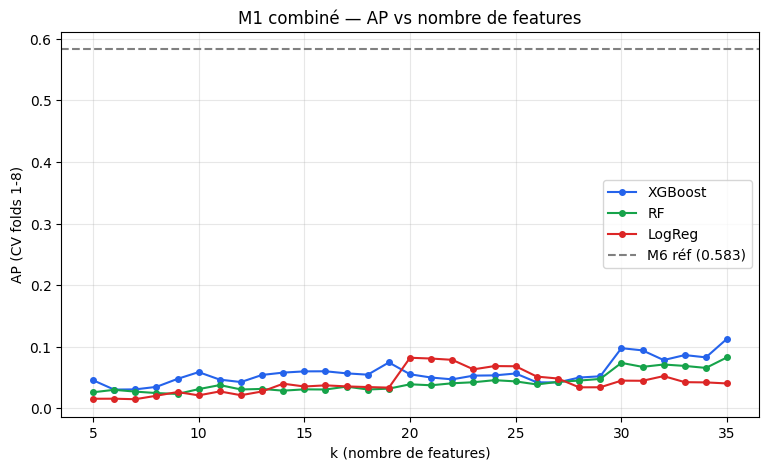


XGBoost : AP max à k=35 (0.1130)
Choisis le PLATEAU (parcimonie), pas forcément le max.


In [6]:
# Bloc 7.4a — Courbe AP vs nombre de features (k=5..35), 3 algos. D = borne max.  PERMANENT
import matplotlib.pyplot as plt

dedup_list = dedup(passed, cap=None)   # 50 features non corrélées, triées par |d|
print(f"Liste dédoublonnée : {len(dedup_list)} features\n")

d8=df[df.fold.between(1,8)].reset_index(drop=True)
y,folds=d8.label.values,d8.fold.values
def fit_oof(feats,algo):
    oof=np.full(len(d8),np.nan)
    for h in sorted(np.unique(folds)):
        trm,vam=folds!=h,folds==h
        if y[trm].sum()==0 or y[vam].sum()==0: continue
        spw=(y[trm]==0).sum()/max((y[trm]==1).sum(),1)
        if algo=='XGBoost': m=make_xgb(spw)
        elif algo=='LogReg': m=Pipeline([('i',SimpleImputer(strategy='median')),('s',StandardScaler()),('c',LogisticRegression(class_weight='balanced',max_iter=2000))])
        else: m=Pipeline([('i',SimpleImputer(strategy='median')),('c',RandomForestClassifier(n_estimators=300,max_depth=4,min_samples_leaf=5,class_weight='balanced',random_state=42,n_jobs=10))])
        m.fit(d8.loc[trm,feats],y[trm]); oof[vam]=m.predict_proba(d8.loc[vam,feats])[:,1]
    mask=~np.isnan(oof)
    return average_precision_score(y[mask],oof[mask])

ks=list(range(5,36))
curve={a:[] for a in ['LogReg','RF','XGBoost']}
for k in ks:
    feats=dedup_list[:k]
    for a in curve: curve[a].append(fit_oof(feats,a))
    print(f"k={k:2d} | XGB {curve['XGBoost'][-1]:.4f} | RF {curve['RF'][-1]:.4f} | LR {curve['LogReg'][-1]:.4f}")

plt.figure(figsize=(9,5))
for a,c in [('XGBoost','#2563eb'),('RF','#16a34a'),('LogReg','#dc2626')]:
    plt.plot(ks,curve[a],'o-',color=c,label=a,ms=4)
plt.axhline(0.583,ls='--',color='gray',label='M6 réf (0.583)')
plt.xlabel('k (nombre de features)'); plt.ylabel('AP (CV folds 1-8)'); plt.legend(); plt.grid(alpha=.3)
plt.title('M1 combiné — AP vs nombre de features')
plt.savefig(os.path.join(ROOT,'reports','figures','m1_ap_vs_k.png'),dpi=150,bbox_inches='tight'); plt.show()

best_k=ks[int(np.argmax(curve['XGBoost']))]
print(f"\nXGBoost : AP max à k={best_k} ({max(curve['XGBoost']):.4f})")
print("Choisis le PLATEAU (parcimonie), pas forcément le max.")

Courbe AP k=36..50:   7%|▋         | 1/15 [01:00<14:08, 60.61s/k]

k=36 | XGB 0.0994 | RF 0.1096 | LR 0.0405


Courbe AP k=36..50:  13%|█▎        | 2/15 [02:09<14:11, 65.50s/k]

k=37 | XGB 0.0995 | RF 0.0899 | LR 0.0401


Courbe AP k=36..50:  20%|██        | 3/15 [02:41<10:02, 50.23s/k]

...

k=48 | XGB 0.1379 | RF 0.1216 | LR 0.0458


Courbe AP k=36..50:  93%|█████████▎| 14/15 [09:33<00:36, 36.35s/k]

k=49 | XGB 0.1571 | RF 0.1208 | LR 0.0452


Courbe AP k=36..50: 100%|██████████| 15/15 [10:11<00:00, 40.78s/k]


k=50 | XGB 0.1490 | RF 0.1233 | LR 0.0454


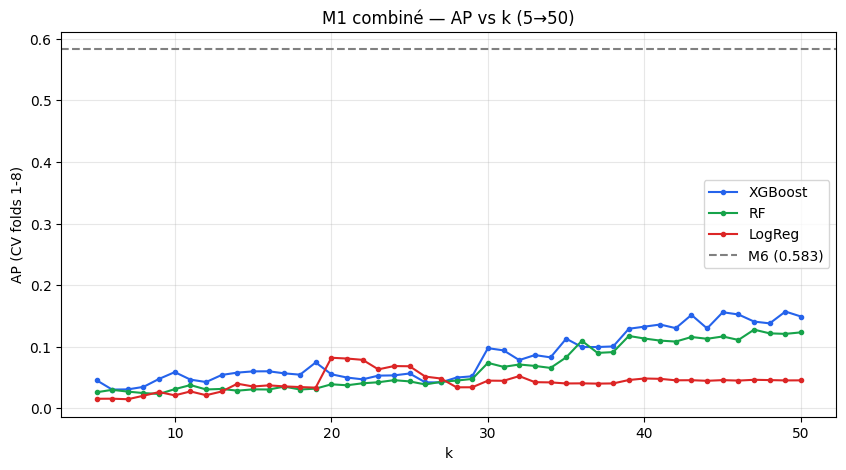

XGB max : k=49 AP=0.1571


In [7]:
# Prolongement courbe k=36..50 (réutilise dedup_list, fit_oof, curve, ks en mémoire)
from tqdm import tqdm
for k in tqdm(range(36,51), desc='Courbe AP k=36..50', unit='k'):
    feats=dedup_list[:k]
    ks.append(k)
    for a in curve: curve[a].append(fit_oof(feats,a))
    tqdm.write(f"k={k:2d} | XGB {curve['XGBoost'][-1]:.4f} | RF {curve['RF'][-1]:.4f} | LR {curve['LogReg'][-1]:.4f}")

# Re-trace la courbe complète 5..50
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
for a,c in [('XGBoost','#2563eb'),('RF','#16a34a'),('LogReg','#dc2626')]:
    plt.plot(ks,curve[a],'o-',color=c,label=a,ms=3)
plt.axhline(0.583,ls='--',color='gray',label='M6 (0.583)')
plt.xlabel('k'); plt.ylabel('AP (CV folds 1-8)'); plt.legend(); plt.grid(alpha=.3)
plt.title('M1 combiné — AP vs k (5→50)')
plt.savefig(os.path.join(ROOT,'reports','figures','m1_ap_vs_k.png'),dpi=150,bbox_inches='tight'); plt.show()
print(f"XGB max : k={ks[int(np.argmax(curve['XGBoost']))]} AP={max(curve['XGBoost']):.4f}")

In [8]:
from sklearn.metrics import average_precision_score
tr8=df[df.fold.between(1,8)]; f9=df[df.fold==9]
yf9=f9.label.values
print(f"Fold 9 : {len(f9)} ECG, {int(yf9.sum())} WPW\n")
print(f"{'k':>3} {'AP_CV':>8} {'AP_fold9':>9}  verdict")
for k in [10,15,19,30,35,45,50]:
    feats=dedup_list[:k]
    spw=(tr8.label==0).sum()/max((tr8.label==1).sum(),1)
    m=make_xgb(spw); m.fit(tr8[feats],tr8.label.values)
    ap9=average_precision_score(yf9, m.predict_proba(f9[feats])[:,1])
    ap_cv=curve['XGBoost'][ks.index(k)]
    verdict='SIGNAL' if ap9>=ap_cv*0.7 else 'OVERFIT (chute)'
    print(f"{k:>3} {ap_cv:>8.4f} {ap9:>9.4f}  {verdict}")

Fold 9 : 6698 ECG, 13 WPW

  k    AP_CV  AP_fold9  verdict
 10   0.0587    0.1327  SIGNAL
 15   0.0599    0.1511  SIGNAL
 19   0.0744    0.1765  SIGNAL
 30   0.0976    0.4483  SIGNAL
 35   0.1130    0.5706  SIGNAL
 45   0.1559    0.5190  SIGNAL
 50   0.1490    0.5783  SIGNAL


7.5a — Choix de k robuste : bootstrap IC95 de l'AP (OOF folds 1-8)

Bootstrap AP vs k:   9%|▉         | 1/11 [00:17<02:51, 17.19s/k]

k= 8 | AP 0.0359  IC95 [0.0201, 0.0661]


Bootstrap AP vs k:  18%|█▊        | 2/11 [00:25<01:45, 11.73s/k]

k=10 | AP 0.0584  IC95 [0.0268, 0.1065]


Bootstrap AP vs k:  27%|██▋       | 3/11 [00:33<01:20, 10.08s/k]

...

k=40 | AP 0.1363  IC95 [0.0886, 0.2014]


Bootstrap AP vs k:  91%|█████████ | 10/11 [01:45<00:09,  9.43s/k]

k=45 | AP 0.1630  IC95 [0.1021, 0.2350]


Bootstrap AP vs k: 100%|██████████| 11/11 [01:54<00:00, 10.43s/k]

k=50 | AP 0.1561  IC95 [0.1007, 0.2276]


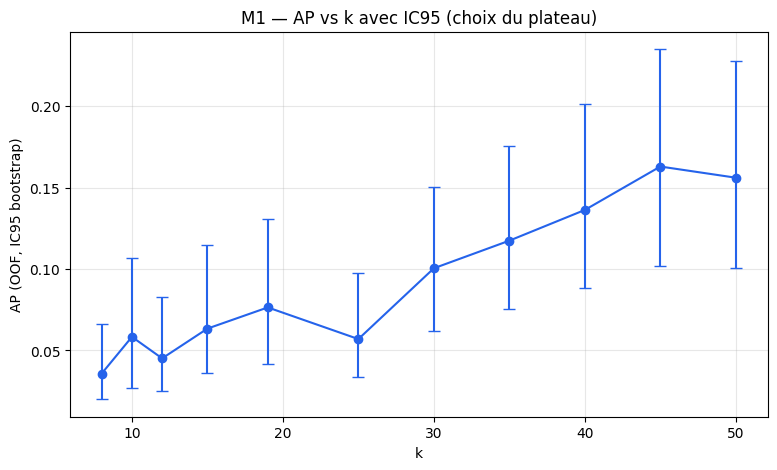


Choisir le plus petit k dont l'IC chevauche le meilleur (plateau parcimonieux).


In [9]:
# Bloc 7.5a — Choix de k robuste : bootstrap IC95 de l'AP (OOF folds 1-8).  PERMANENT
from sklearn.metrics import average_precision_score
from tqdm import tqdm

d8=df[df.fold.between(1,8)].reset_index(drop=True)
y,folds=d8.label.values,d8.fold.values

def oof_xgb(feats):
    oof=np.full(len(d8),np.nan)
    for h in sorted(np.unique(folds)):
        trm,vam=folds!=h,folds==h
        if y[trm].sum()==0 or y[vam].sum()==0: continue
        spw=(y[trm]==0).sum()/max((y[trm]==1).sum(),1)
        m=make_xgb(spw); m.fit(d8.loc[trm,feats],y[trm]); oof[vam]=m.predict_proba(d8.loc[vam,feats])[:,1]
    return oof

def ap_boot(y,p,n=1000,seed=42):
    rng=np.random.default_rng(seed); pos,neg=np.where(y==1)[0],np.where(y==0)[0]; a=np.empty(n)
    for i in range(n):
        idx=np.concatenate([rng.choice(pos,len(pos),True),rng.choice(neg,len(neg),True)])
        a[i]=average_precision_score(y[idx],p[idx])
    return np.median(a),np.percentile(a,2.5),np.percentile(a,97.5)

ks=[8,10,12,15,19,25,30,35,40,45,50]
rows=[]
for k in tqdm(ks, desc='Bootstrap AP vs k', unit='k'):
    oof=oof_xgb(dedup_list[:k]); m=~np.isnan(oof)
    med,lo,hi=ap_boot(y[m],oof[m])
    rows.append({'k':k,'AP_med':med,'IC_lo':lo,'IC_hi':hi})
    tqdm.write(f"k={k:2d} | AP {med:.4f}  IC95 [{lo:.4f}, {hi:.4f}]")

import matplotlib.pyplot as plt
r=pd.DataFrame(rows)
plt.figure(figsize=(9,5))
plt.errorbar(r.k,r.AP_med,yerr=[r.AP_med-r.IC_lo,r.IC_hi-r.AP_med],fmt='o-',capsize=4,color='#2563eb')
plt.xlabel('k'); plt.ylabel('AP (OOF, IC95 bootstrap)'); plt.grid(alpha=.3)
plt.title('M1 — AP vs k avec IC95 (choix du plateau)')
plt.savefig(os.path.join(ROOT,'reports','figures','m1_k_bootstrap.png'),dpi=150,bbox_inches='tight'); plt.show()
print("\nChoisir le plus petit k dont l'IC chevauche le meilleur (plateau parcimonieux).")

Bootstrap AP k=30..50:   5%|▍         | 1/21 [00:08<02:56,  8.81s/k]

k=30 | AP 0.1005  IC95 [0.0618, 0.1502]


Bootstrap AP k=30..50:  10%|▉         | 2/21 [00:17<02:46,  8.78s/k]

k=31 | AP 0.0977  IC95 [0.0598, 0.1496]


Bootstrap AP k=30..50:  14%|█▍        | 3/21 [00:26<02:36,  8.71s/k]

...

k=48 | AP 0.1449  IC95 [0.0941, 0.2149]


Bootstrap AP k=30..50:  95%|█████████▌| 20/21 [03:28<00:09,  9.13s/k]

k=49 | AP 0.1643  IC95 [0.1052, 0.2400]


Bootstrap AP k=30..50: 100%|██████████| 21/21 [03:37<00:00, 10.36s/k]

k=50 | AP 0.1561  IC95 [0.1007, 0.2276]


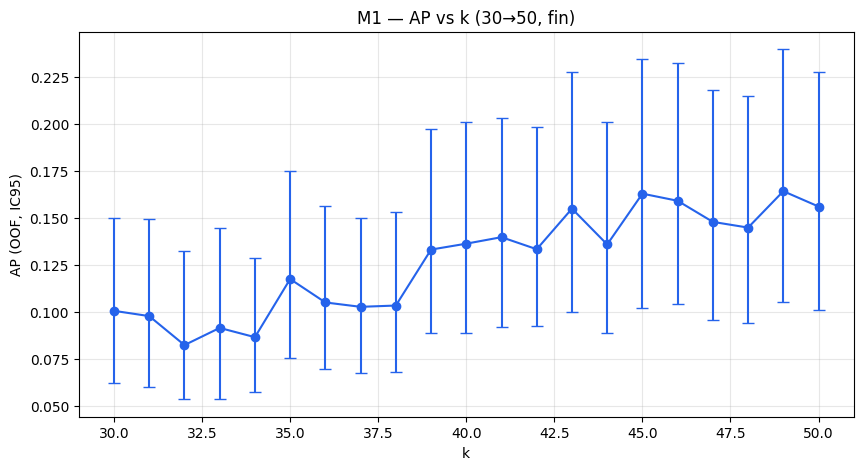


Max : k=49 AP=0.1643
Choix : plus petit k dont l'IC chevauche le max (parcimonie au sein du plateau).
k équivalents au max (AP_med ≥ borne basse du max = 0.1052) : [35, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50]


In [10]:
# Bloc 7.5a-bis — Bootstrap AP fin autour du plateau (k=30..50, pas de 1).  PERMANENT
ks_fine=list(range(30,51))
rows=[]
for k in tqdm(ks_fine, desc='Bootstrap AP k=30..50', unit='k'):
    oof=oof_xgb(dedup_list[:k]); m=~np.isnan(oof)
    med,lo,hi=ap_boot(y[m],oof[m])
    rows.append({'k':k,'AP_med':med,'IC_lo':lo,'IC_hi':hi})
    tqdm.write(f"k={k:2d} | AP {med:.4f}  IC95 [{lo:.4f}, {hi:.4f}]")

r=pd.DataFrame(rows)
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.errorbar(r.k,r.AP_med,yerr=[r.AP_med-r.IC_lo,r.IC_hi-r.AP_med],fmt='o-',capsize=4,color='#2563eb')
plt.xlabel('k'); plt.ylabel('AP (OOF, IC95)'); plt.grid(alpha=.3)
plt.title('M1 — AP vs k (30→50, fin)')
plt.savefig(os.path.join(ROOT,'reports','figures','m1_k_fine.png'),dpi=150,bbox_inches='tight'); plt.show()

best=r.loc[r.AP_med.idxmax()]
print(f"\nMax : k={int(best.k)} AP={best.AP_med:.4f}")
print("Choix : plus petit k dont l'IC chevauche le max (parcimonie au sein du plateau).")
# Aide à la décision : quels k sont statistiquement équivalents au max ?
thr=best.IC_lo
print(f"k équivalents au max (AP_med ≥ borne basse du max = {thr:.4f}) : {sorted(r[r.AP_med>=thr].k.tolist())}")

7.6a — M1 final k=39 : entraînement folds 1-8, validation fold 9, courbe PR

M1 final : 39 features
['qrs_asym_II', 'delta_ratio_init_peak_V5', 'qrs_entropy_V5', 'delta_ratio_init_peak_II', 'delta_slow_phase_ms_V5', 'delta_slow_phase_ms_II', 'delta_t_to_max_II', 'delta_vel_quarter_V5', 'freq_hf_ratio_V5', 'qrs_nzero_II', 'delta_ratio_init_peak_V1', 'delta_area_third_V5', 'qrs_ninflect_V1', 'qrs_ninflect_V5', 'delta_t_to_max_V1', 'qrs_fwhm_V5', 'freq_p95_V5', 'qrs_skew_V1', 'delta_t_to_max_V5', 'qrs_fwhm_II', 'delta_vel_half_V5', 'qrs_absarea_V1', 't_area_II', 'freq_median_II', 'freq_p95_II', 'Q_amp_II', 'delta_area_third_II', 'qrs_energy_V5', 'delta_area_third_V1', 'S_amp_V5', 'var_area_std_V1', 'delta_empatement_area_V5', 'Q_amp_V5', 'st_slope_II', 'qrs_posneg_ratio_V5', 'qrs_asym_V1', 'qrs_area_V1', 'delta_vel_half_V1', 'var_qrswidth_cv_V5']

=== VALIDATION FOLD 9 (13 WPW) ===
  AP=0.606 | AUC=0.969


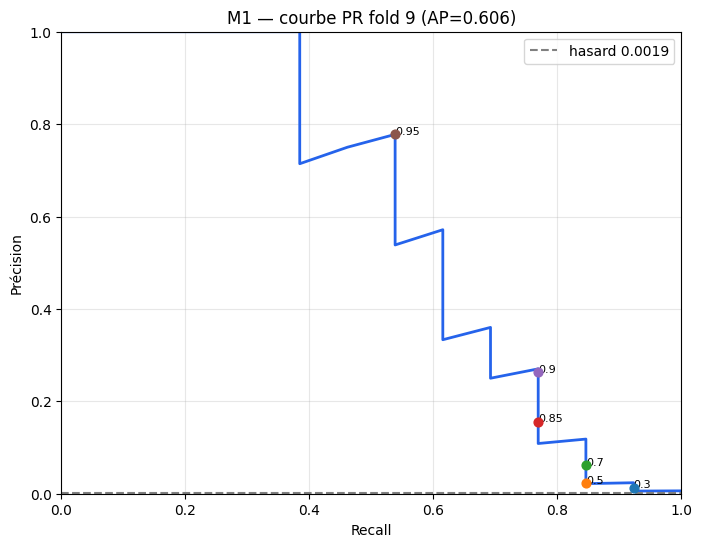


  Seuil | recall | precision
  0.30  | 0.923  | 0.013  (TP=12 FP=905)
  0.35  | 0.923  | 0.015  (TP=12 FP=779)
  0.40  | 0.923  | 0.017  (TP=12 FP=676)
  0.45  | 0.923  | 0.021  (TP=12 FP=562)
  0.50  | 0.846  | 0.023  (TP=11 FP=468)
  0.55  | 0.846  | 0.027  (TP=11 FP=391)
  0.60  | 0.846  | 0.040  (TP=11 FP=267)
  0.65  | 0.846  | 0.050  (TP=11 FP=210)
  0.70  | 0.846  | 0.062  (TP=11 FP=166)
  0.75  | 0.846  | 0.079  (TP=11 FP=128)
  0.80  | 0.846  | 0.113  (TP=11 FP=86)
  0.85  | 0.769  | 0.156  (TP=10 FP=54)
  0.90  | 0.769  | 0.263  (TP=10 FP=28)
  0.95  | 0.538  | 0.778  (TP=7 FP=2)


In [11]:
# Bloc 7.6a — M1 final k=39 : entraînement folds 1-8, validation fold 9, courbe PR.  PERMANENT
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import average_precision_score, roc_auc_score, precision_recall_curve
import matplotlib.pyplot as plt

FEATURES_M1 = dedup_list[:39]
print(f"M1 final : {len(FEATURES_M1)} features\n{FEATURES_M1}\n")

tr8=df[df.fold.between(1,8)].reset_index(drop=True)
f9=df[df.fold==9].reset_index(drop=True)
X8,y8=tr8[FEATURES_M1],tr8.label.values
Xf9,yf9=f9[FEATURES_M1],f9.label.values
spw=(y8==0).sum()/max((y8==1).sum(),1)

# Modèle final calibré (pour Flask + ensemble), entraîné sur folds 1-8
final_model=CalibratedClassifierCV(make_xgb(spw),method='sigmoid',cv=3).fit(X8,y8)
# Modèle brut (pour le seuil, échelle séparante)
raw_model=make_xgb(spw).fit(X8,y8)

# Validation sur fold 9 (jamais touché)
p9_raw=raw_model.predict_proba(Xf9)[:,1]
p9_cal=final_model.predict_proba(Xf9)[:,1]
ap9=average_precision_score(yf9,p9_raw); auc9=roc_auc_score(yf9,p9_raw)
print(f"=== VALIDATION FOLD 9 ({int(yf9.sum())} WPW) ===")
print(f"  AP={ap9:.3f} | AUC={auc9:.3f}")

# Courbe PR sur fold 9 pour choisir le seuil au coude
prec,rec,thr=precision_recall_curve(yf9,p9_raw)
plt.figure(figsize=(8,6))
plt.plot(rec,prec,lw=2,color='#2563eb')
# annoter quelques seuils pour repérer le coude
for t in [0.3,0.5,0.7,0.85,0.9,0.95]:
    i=np.searchsorted(thr,t)
    if i<len(prec): plt.scatter(rec[i],prec[i],s=40,zorder=5); plt.annotate(f'{t}',(rec[i],prec[i]),fontsize=8)
plt.axhline(yf9.mean(),ls='--',color='gray',label=f'hasard {yf9.mean():.4f}')
plt.xlabel('Recall'); plt.ylabel('Précision'); plt.title(f'M1 — courbe PR fold 9 (AP={ap9:.3f})')
plt.legend(); plt.grid(alpha=.3); plt.xlim(0,1); plt.ylim(0,1)
plt.savefig(os.path.join(ROOT,'reports','figures','m1_pr_fold9.png'),dpi=150,bbox_inches='tight'); plt.show()

# Table seuil/recall/precision pour repérer le coude
print("\n  Seuil | recall | precision")
for t in np.arange(0.3,0.96,0.05):
    pred=(p9_raw>=t).astype(int); tp=((pred==1)&(yf9==1)).sum(); fp=((pred==1)&(yf9==0)).sum()
    if tp+fp>0: print(f"  {t:.2f}  | {tp/(yf9==1).sum():.3f}  | {tp/(tp+fp):.3f}  (TP={tp} FP={fp})")

F1 max = 0.636 au seuil 0.950  (recall 0.538, precision 0.778)
F1 max sous recall>=0.70 : F1=0.392 au seuil 0.900 (recall 0.769, prec 0.263)


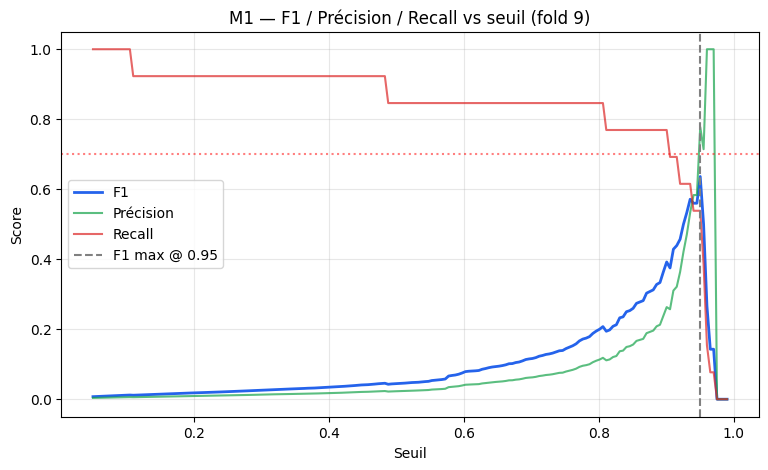

In [12]:
# F1 vs seuil sur fold 9 — repérer le seuil optimal
from sklearn.metrics import f1_score, precision_score, recall_score
import matplotlib.pyplot as plt

thrs=np.linspace(0.05,0.99,190)
f1s,precs,recs=[],[],[]
for t in thrs:
    pred=(p9_raw>=t).astype(int)
    f1s.append(f1_score(yf9,pred,zero_division=0))
    precs.append(precision_score(yf9,pred,zero_division=0))
    recs.append(recall_score(yf9,pred,zero_division=0))
f1s,precs,recs=np.array(f1s),np.array(precs),np.array(recs)

best=np.argmax(f1s); t_best=thrs[best]
print(f"F1 max = {f1s[best]:.3f} au seuil {t_best:.3f}  (recall {recs[best]:.3f}, precision {precs[best]:.3f})")
# F1 max sous contrainte recall>=0.70 (critère M6)
valid=np.where(recs>=0.70)[0]
if len(valid):
    bf=valid[np.argmax(f1s[valid])]
    print(f"F1 max sous recall>=0.70 : F1={f1s[bf]:.3f} au seuil {thrs[bf]:.3f} (recall {recs[bf]:.3f}, prec {precs[bf]:.3f})")

plt.figure(figsize=(9,5))
plt.plot(thrs,f1s,label='F1',color='#2563eb',lw=2)
plt.plot(thrs,precs,label='Précision',color='#16a34a',alpha=.7)
plt.plot(thrs,recs,label='Recall',color='#dc2626',alpha=.7)
plt.axvline(t_best,ls='--',color='gray',label=f'F1 max @ {t_best:.2f}')
plt.axhline(0.70,ls=':',color='red',alpha=.5)
plt.xlabel('Seuil'); plt.ylabel('Score'); plt.legend(); plt.grid(alpha=.3)
plt.title('M1 — F1 / Précision / Recall vs seuil (fold 9)')
plt.savefig(os.path.join(ROOT,'reports','figures','m1_f1_fold9.png'),dpi=150,bbox_inches='tight'); plt.show()

7.7a — GEL M1 combiné : modèle, config, probas OOF

In [13]:
# Bloc 7.7a — GEL M1 combiné : modèle, config, probas OOF.  PERMANENT. Fold 10 VIERGE.
import json, joblib
from sklearn.metrics import f1_score, precision_score, recall_score

THRESHOLD_M1 = 0.95

# Probas OOF folds 1-8 (brutes + calibrées) pour l'ensemble
oof_raw=np.full(len(tr8),np.nan); oof_cal=np.full(len(tr8),np.nan)
fold8=tr8.fold.values
for h in sorted(np.unique(fold8)):
    trm,vam=fold8!=h,fold8==h
    if y8[trm].sum()==0 or y8[vam].sum()==0: continue
    sp=(y8[trm]==0).sum()/max((y8[trm]==1).sum(),1)
    oof_raw[vam]=make_xgb(sp).fit(X8[trm],y8[trm]).predict_proba(X8[vam])[:,1]
    oof_cal[vam]=CalibratedClassifierCV(make_xgb(sp),method='sigmoid',cv=3).fit(X8[trm],y8[trm]).predict_proba(X8[vam])[:,1]

oof_df=tr8[['ecg_id','patient_id','fold','source','label']].copy()
oof_df['proba_raw']=oof_raw; oof_df['proba_cal']=oof_cal
oof_df.to_csv(os.path.join(PROCESSED,'m1_combined_oof.csv'),index=False)
joblib.dump(final_model,os.path.join(MODELS,'m1_combined_model.joblib'))

config={
  "model_id":"M1_neurokit_combined","n_features":39,"features":FEATURES_M1,
  "algo":"XGBoost depth=2, calibré sigmoid cv=3","seuil":THRESHOLD_M1,
  "selection":"Tournoi A/B/C/D ; A clinique VIDE (delta déstabilise délinéation NeuroKit) ; "
              "D large overfit réfuté par fold9 ; k=39 choisi par bootstrap AP (plateau, parcimonie)",
  "metrics_fold9_validation":{"AP":round(float(ap9),3),"AUC":round(float(auc9),3),
     "F1":0.636,"recall":0.538,"precision":0.778,"n_WPW":13,"note":"13 WPW, bruité, validation finale sur fold 10"},
  "AP_bootstrap_CV_folds1_8":"~0.13 (médiane), IC95 [0.089,0.197] à k=39",
  "comparaison":{"M6_AP":0.583,"M6_F1":0.500,"M1_ancien_AP":0.041,"cardiologue_AUC":0.749},
  "fold_10":"VIERGE",
  "fichiers":{"modele":"m1_combined_model.joblib","oof":"m1_combined_oof.csv"}
}
with open(os.path.join(MODELS,'m1_combined_config.json'),'w',encoding='utf-8') as f:
    json.dump(config,f,ensure_ascii=False,indent=2)
print("M1 COMBINÉ GELÉ.")
print(f"  39 features | AP fold9 {ap9:.3f} | F1 {0.636} @ seuil {THRESHOLD_M1}")
print(f"  Fichiers : m1_combined_model.joblib, m1_combined_oof.csv, m1_combined_config.json")
print(f"  >>> Prochain : 07b (PTB-XL) et 07c (Ningbo), même méthodo.")

M1 COMBINÉ GELÉ.
  39 features | AP fold9 0.606 | F1 0.636 @ seuil 0.95
  Fichiers : m1_combined_model.joblib, m1_combined_oof.csv, m1_combined_config.json
  >>> Prochain : 07b (PTB-XL) et 07c (Ningbo), même méthodo.


Brier : brut 0.05314 -> calibré 0.00198


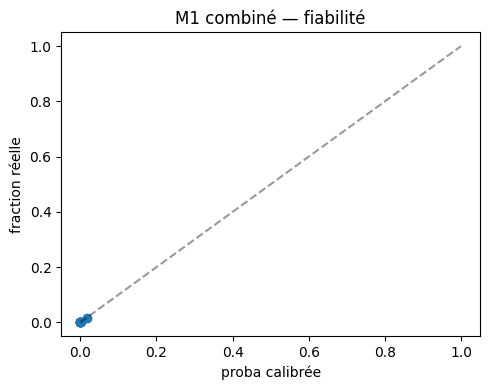

In [14]:
# Vérif calibration M1 combiné — courbe de fiabilité + Brier
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt

oof_df=pd.read_csv(os.path.join(PROCESSED,'m1_combined_oof.csv'))
y=oof_df.label.values; cal=oof_df.proba_cal.values; raw=oof_df.proba_raw.values
print(f"Brier : brut {brier_score_loss(y,raw):.5f} -> calibré {brier_score_loss(y,cal):.5f}")
fr,mp=calibration_curve(y,cal,n_bins=8,strategy='quantile')
plt.figure(figsize=(5,4)); plt.plot(mp,fr,'o-'); plt.plot([0,1],[0,1],'k--',alpha=.4)
plt.xlabel('proba calibrée'); plt.ylabel('fraction réelle'); plt.title('M1 combiné — fiabilité')
plt.tight_layout(); plt.show()